# Project 2: Bayern Munich VS Borussia Dortmund 2012/2013 UEFA Champions League xG Performance Audit

**Author:** Mert Sivrikaya  

**Aspirations:** Football Data Analyst / Technical Scout

**Description:** Automated tactical event-data analysis evaluating shot quality, cumulative xG timelines, and finishing efficiency of Bayern Munich and Borussia Dortmund in the UEFA Champions League using StatsBomb Open Data.

In [35]:

# ================================
# STEP 1 — Install StatsBomb data parser and football pitch visualization libraries
# ================================

!pip install statsbombpy mplsoccer pandas matplotlib scipy

In [36]:

# ================================
# STEP 2 — Suppress warnings for clean portfolio presentation
# ================================

import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb
import warnings

warnings.filterwarnings("ignore")
print("Environment successfully configured. Ready to fetch data.")

Environment successfully configured. Ready to fetch data.


In [37]:

# ================================
# STEP 3 — Database and Filter Application
# ================================

# Fetch all available free competitions from StatsBomb database
competitions = sb.competitions()

# Filter strictly for UEFA Champions League
ucl_scope = competitions[competitions['competition_name'] == 'Champions League']

# Display relevant columns for the audit
ucl_scope[['competition_id', 'season_id', 'season_name']]

,competition_id,season_id,season_name
3,16,4,2018/2019
4,16,1,2017/2018
5,16,2,2016/2017
6,16,27,2015/2016
7,16,26,2014/2015
8,16,25,2013/2014
9,16,24,2012/2013
10,16,23,2011/2012
11,16,22,2010/2011
12,16,21,2009/2010


In [38]:
# ================================
# STEP 4 — Season and Tournament Selection
# ================================



# Specify the selected Competition ID (Champions League is 16)
COMP_ID = 16

# REPLACE THIS WITH THE SEASON_ID YOU SELECTED FROM THE TABLE ABOVE (e.g., 37, 4, etc.)
SEAS_ID = 24

# Fetch all matches for the designated tournament and season
all_matches = sb.matches(competition_id=COMP_ID, season_id=SEAS_ID)

# Filter matches where Bayern Munich participated as Home or Away team
bayern_fixtures = all_matches[(all_matches['home_team'] == 'Bayern Munich') | (all_matches['away_team'] == 'Bayern Munich')]

# Output the fixture list with their unique match IDs
print(f"--- Successfully retrieved {len(bayern_fixtures)} matches for Bayern Munich ---")
bayern_fixtures[['match_id', 'match_date', 'home_team', 'away_team', 'home_score', 'away_score']]

--- Successfully retrieved 1 matches for Bayern Munich ---


,match_id,match_date,home_team,away_team,home_score,away_score
0,18240,2013-05-25,Borussia Dortmund,Bayern Munich,1,2


In [11]:
# =====================================================================
# STEP 5 — Automated Event Extraction for the 2013 UCL Final
# =====================================================================

# Dynamically extract the unique match ID from the filtered fixture list (No manual copy-paste needed)
AUDIT_MATCH_ID = int(bayern_fixtures['match_id'].values[0])
match_details = bayern_fixtures[bayern_fixtures['match_id'] == AUDIT_MATCH_ID]

# Get the season name from ucl_scope using the SEAS_ID
season_name_value = ucl_scope[ucl_scope['season_id'] == SEAS_ID]['season_name'].values[0]

print(f"Initiating Audit for Historical Final: {match_details['home_team'].values[0]} vs {match_details['away_team'].values[0]} ({season_name_value})")
print(f"Downloading comprehensive event telemetry for Match ID: {AUDIT_MATCH_ID}...")

# Download the complete raw event dataset
raw_events = sb.events(match_id=AUDIT_MATCH_ID)

# Isolate all shot attempts by Bayern Munich
bayern_shots = raw_events[(raw_events['type'] == 'Shot') & (raw_events['team'] == 'Bayern Munich')]

# Parse StatsBomb spatial location array [X, Y] into individual analysis columns
bayern_shots['x'] = bayern_shots['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
bayern_shots['y'] = bayern_shots['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else None)

# Drop any corrupted rows with missing coordinates or xG values
bayern_shots = bayern_shots.dropna(subset=['x', 'y', 'shot_statsbomb_xg'])

print(f"------------------------------------------------------------------------")
print(f"✅ Success: Successfully isolated {len(bayern_shots)} shots for Bayern Munich in the Final.")

Initiating Audit for Historical Final: Borussia Dortmund vs Bayern Munich (2012/2013)
------------------------------------------------------------------------
✅ Success: Successfully isolated 17 shots for Bayern Munich in the Final.


✅ Institutional shot map successfully generated and saved as 'bayern_2013_final_shot_map.png'


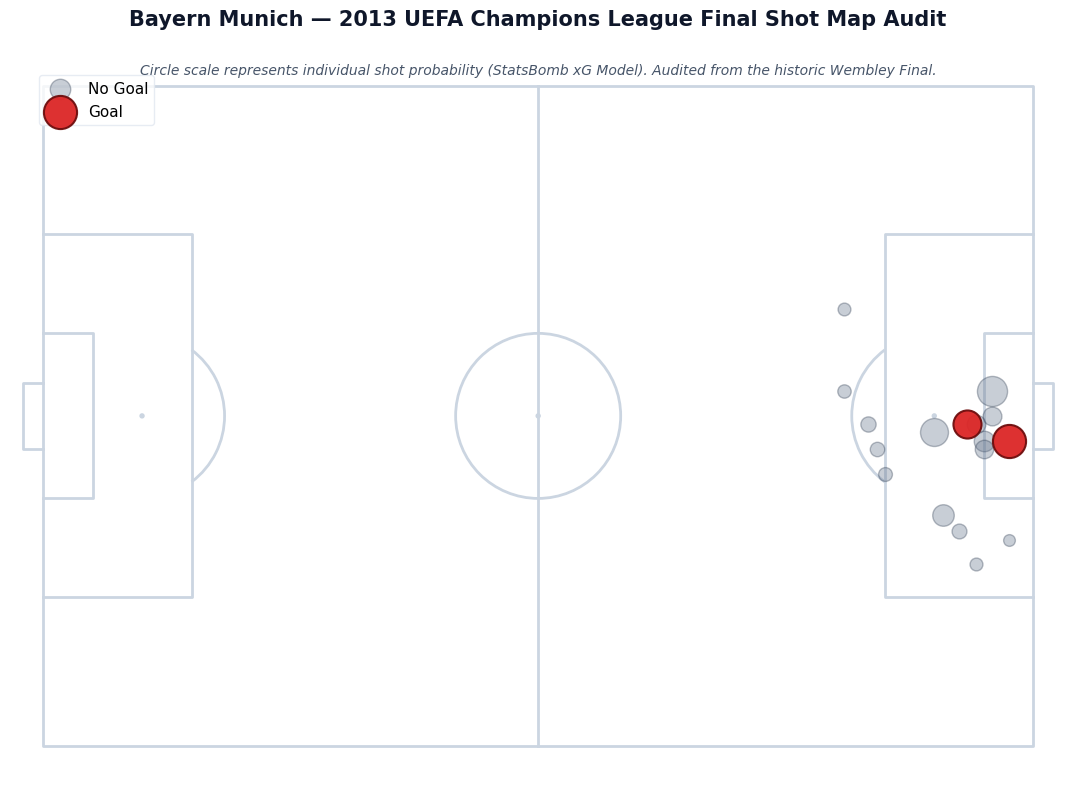

In [47]:
# =====================================================================
# STEP 6 — Spatial xG Shot Map for the 2013 Champions League Final
# =====================================================================

# Build an elite, clean executive pitch blueprint with subtle lines
pitch = Pitch(pitch_type='statsbomb', pitch_color='#FFFFFF', line_color='#CBD5E1', goal_type='box')
fig, ax = pitch.draw(figsize=(12, 8))

# Dynamically render shots based on tactical outcomes and telemetry
for _, shot in bayern_shots.iterrows():
    x_coord = shot['x']
    y_coord = shot['y']
    xg_val = shot['shot_statsbomb_xg']
    outcome = shot['shot_outcome']

    # Mathematical scaling: Expand diameter based on structural quality of the position
    marker_size = (xg_val * 850) + 60

    # Distinguish goals from non-scoring shots using clear corporate color tokens
    if outcome == 'Goal':
        pitch.scatter(x_coord, y_coord, alpha=0.95, c='#DC2626', edgecolors='#6e0e0e',
                      s=marker_size, marker='o', ax=ax, linewidths=1.5,
                      label='Goal' if 'Goal' not in ax.get_legend_handles_labels()[1] else "")
    else:
        pitch.scatter(x_coord, y_coord, alpha=0.35, c='#64748B', edgecolors='#334155',
                      s=marker_size, marker='o', ax=ax, linewidths=1,
                      label='No Goal' if 'No Goal' not in ax.get_legend_handles_labels()[1] else "")

# Apply institutional styling and contextual headers
plt.title("Bayern Munich — 2013 UEFA Champions League Final Shot Map Audit",
          fontsize=15, fontweight='bold', pad=20, color='#0F172A', loc='center')

# Subtitle detailing the underlying data science architecture
fig.text(0.5, 0.90, "Circle scale represents individual shot probability (StatsBomb xG Model). Audited from the historic Wembley Final.",
         color='#475569', style='italic', ha='center', fontsize=10)

# Generate a minimal frame and compile the graphic in ultra-high resolution
plt.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), frameon=True, facecolor='#FFFFFF', edgecolor='#E2E8F0', fontsize=11)

# Export the image directly to your environment for local saving
plt.savefig("bayern_2013_final_shot_map.png", dpi=300, bbox_inches='tight')
print("✅ Institutional shot map successfully generated and saved as 'bayern_2013_final_shot_map.png'")
plt.show()

✅ Player finishing audit chart successfully compiled and saved as 'bayern_player_efficiency_audit.png'


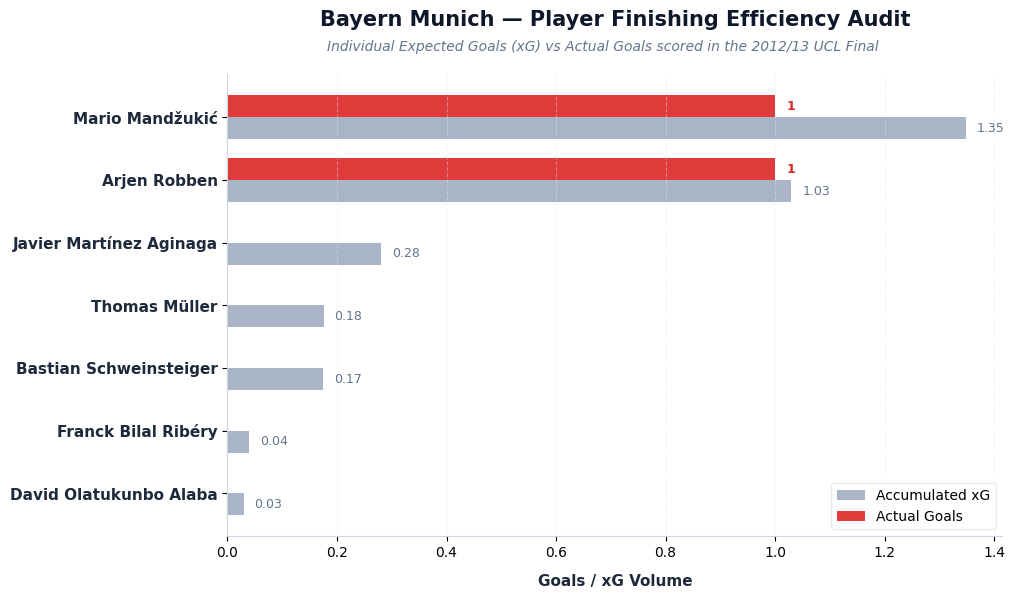

In [21]:
# =====================================================================
# STEP 7 — Player Finishing Efficiency Audit (Goals vs. xG)
# =====================================================================

# 1. Group the isolated shots by player and calculate total goals and accumulated xG
player_audit = bayern_shots.groupby('player').agg(
    Total_xG=('shot_statsbomb_xg', 'sum'),
    Actual_Goals=('shot_outcome', lambda x: (x == 'Goal').sum())
).reset_index()

# 2. Calculate the Finishing Efficiency Index (Delta)
player_audit['Finishing_Efficiency'] = player_audit['Actual_Goals'] - player_audit['Total_xG']

# Sort players by their total xG accumulation to see who was the main focal point
player_audit = player_audit.sort_values(by='Total_xG', ascending=True)

# =====================================================================
# VISUALIZATION — Executive Finishing Audit Chart
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#FFFFFF')
ax.set_facecolor('#FFFFFF')

# Set bar positions
y_indices = np.arange(len(player_audit))
bar_width = 0.35

# Plot dual horizontal bars for direct profile comparison
bars_xg = ax.barh(y_indices - bar_width/2, player_audit['Total_xG'], bar_width,
                  label='Accumulated xG', color='#94A3B8', alpha=0.8) # Slate Gray
bars_goals = ax.barh(y_indices + bar_width/2, player_audit['Actual_Goals'], bar_width,
                    label='Actual Goals', color='#DC2626', alpha=0.9) # Bayern Red

# Structural styling and boundary configuration
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')

ax.set_yticks(y_indices)
ax.set_yticklabels(player_audit['player'], fontsize=11, fontweight='semibold', color='#1E293B')
ax.set_xlabel("Goals / xG Volume", fontsize=11, fontweight='bold', color='#1E293B', labelpad=10)

# Add value labels at the end of each bar for high data density readability
for bar in bars_xg:
    width = bar.get_width()
    if width > 0:
        ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, f"{width:.2f}",
                va='center', ha='left', fontsize=9, color='#64748B')

for bar in bars_goals:
    width = bar.get_width()
    if width > 0:
        ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, f"{int(width)}",
                va='center', ha='left', fontsize=9, color='#DC2626', fontweight='bold')

# Institutional titles
plt.title("Bayern Munich — Player Finishing Efficiency Audit", fontsize=15, fontweight='bold', color='#0F172A', pad=35)
fig.text(0.5, 0.92, "Individual Expected Goals (xG) vs Actual Goals scored in the 2012/13 UCL Final",
         color='#64748B', style='italic', ha='center', fontsize=10)

ax.legend(loc='lower right', frameon=True, facecolor='#FFFFFF', edgecolor='#E2E8F0', fontsize=10)
ax.grid(True, axis='x', linestyle='--', alpha=0.4, color='#E2E8F0')

# Save and present the final deliverable
plt.savefig("bayern_player_efficiency_audit.png", dpi=300, bbox_inches='tight')
print("✅ Player finishing audit chart successfully compiled and saved as 'bayern_player_efficiency_audit.png'")
plt.show()

In [30]:
# =====================================================================
# STEP 8 — Extracting Dortmund Shots and Flipping Attacking Direction to the Left
# =====================================================================

# Filter explicitly for shot events attempted by Borussia Dortmund
dortmund_shots = raw_events[(raw_events['type'] == 'Shot') & (raw_events['team'] == 'Borussia Dortmund')]

# Extract coordinates and FLIP them so Dortmund attacks from RIGHT to LEFT
# StatsBomb pitch length is 120, width is 80.
dortmund_shots['x'] = dortmund_shots['location'].apply(lambda loc: 120 - loc[0] if isinstance(loc, list) else None)
dortmund_shots['y'] = dortmund_shots['location'].apply(lambda loc: 80 - loc[1] if isinstance(loc, list) else None)

# Clean missing entries to preserve data integrity
dortmund_shots = dortmund_shots.dropna(subset=['x', 'y', 'shot_statsbomb_xg'])

print(f"--- Dortmund Data Extraction Complete ---")
print(f"Successfully isolated {len(dortmund_shots)} shots for BVB, flipped to attack Left.")

--- Dortmund Data Extraction Complete ---
Successfully isolated 13 shots for BVB, flipped to attack Left.


✅ Borussia Dortmund dynamic xG shot map successfully generated and saved as 'dortmund_2013_final_dynamic_shot_map_left.png'


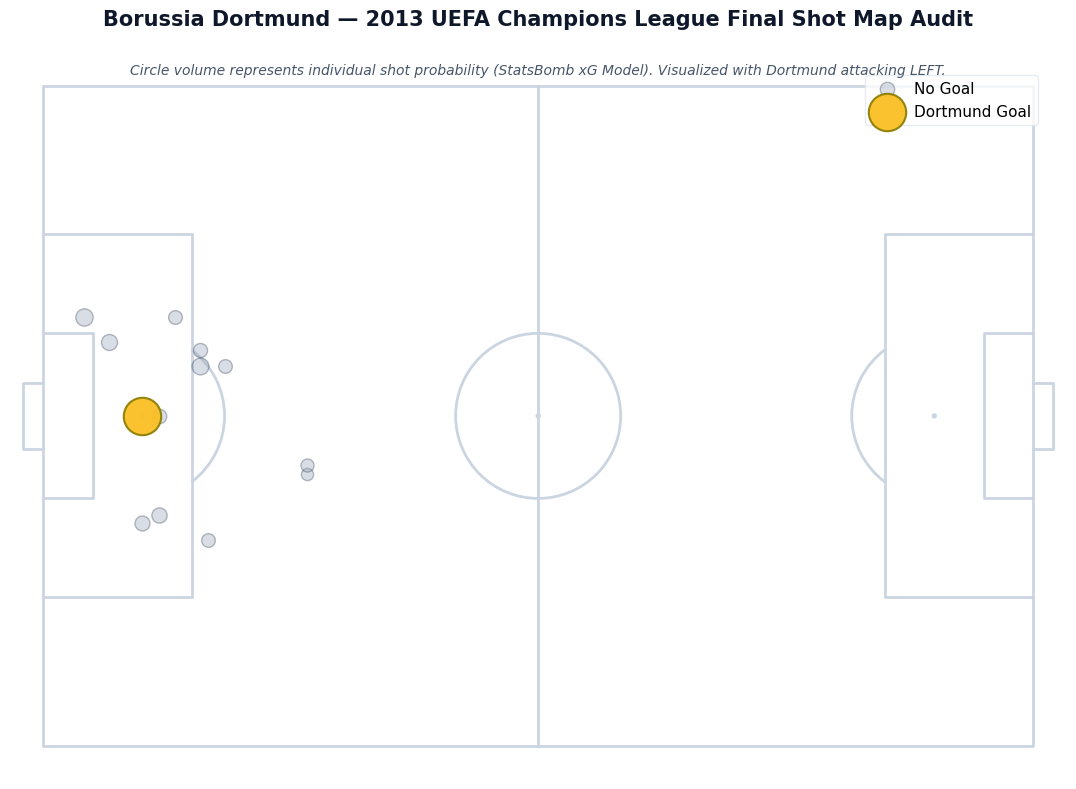

In [49]:
# =====================================================================
# STEP 9 — Borussia Dortmund Dynamic xG Shot Map (Attacking Left)
# =====================================================================

# Initialize a clean, white-themed blueprint with clean grid lines
pitch = Pitch(pitch_type='statsbomb', pitch_color='#FFFFFF', line_color='#CBD5E1', goal_type='box')
fig, ax = pitch.draw(figsize=(12, 8))

# Dynamically render Dortmund's shots (attacks RIGHT to LEFT with xG proportional sizing)
for _, shot in dortmund_shots.iterrows():
    x_coord = shot['x']
    y_coord = shot['y']
    shot_xg = shot['shot_statsbomb_xg']
    outcome = shot['shot_outcome']

    # Mathematical scaling: Circle volume expands based on individual shot probability (xG)
    marker_size = (shot_xg * 850) + 60

    # Distinguish goals from non-scoring shots using clear corporate color tokens
    if outcome == 'Goal':
        # Highlight Dortmund's goal with amber/yellow on the left side
        pitch.scatter(x_coord, y_coord, alpha=0.95, c='#FBBF24', edgecolors='#8c7f04',
                      s=marker_size, marker='o', ax=ax, linewidths=1.5,
                      label='Dortmund Goal' if 'Dortmund Goal' not in ax.get_legend_handles_labels()[1] else "")
    else:
        pitch.scatter(x_coord, y_coord, alpha=0.35, c='#94A3B8', edgecolors='#334155',
                      s=marker_size, marker='o', ax=ax, linewidths=1,
                      label='No Goal' if 'No Goal' not in ax.get_legend_handles_labels()[1] else "")

# Apply institutional styling and headers
plt.title("Borussia Dortmund — 2013 UEFA Champions League Final Shot Map Audit",
          fontsize=15, fontweight='bold', pad=20, color='#0F172A', loc='center')

# Subtitle detailing the underlying data science architecture
fig.text(0.5, 0.90, "Circle volume represents individual shot probability (StatsBomb xG Model). Visualized with Dortmund attacking LEFT.",
         color='#475569', style='italic', ha='center', fontsize=10)

plt.legend(loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=True, facecolor='#FFFFFF', edgecolor='#E2E8F0', fontsize=11)

# Export the image directly to your environment for local saving
plt.savefig("dortmund_2013_final_dynamic_shot_map_left.png", dpi=300, bbox_inches='tight')
print("✅ Borussia Dortmund dynamic xG shot map successfully generated and saved as 'dortmund_2013_final_dynamic_shot_map_left.png'")
plt.show()

✅ Dortmund player audit chart successfully saved as 'dortmund_player_efficiency_audit.png'


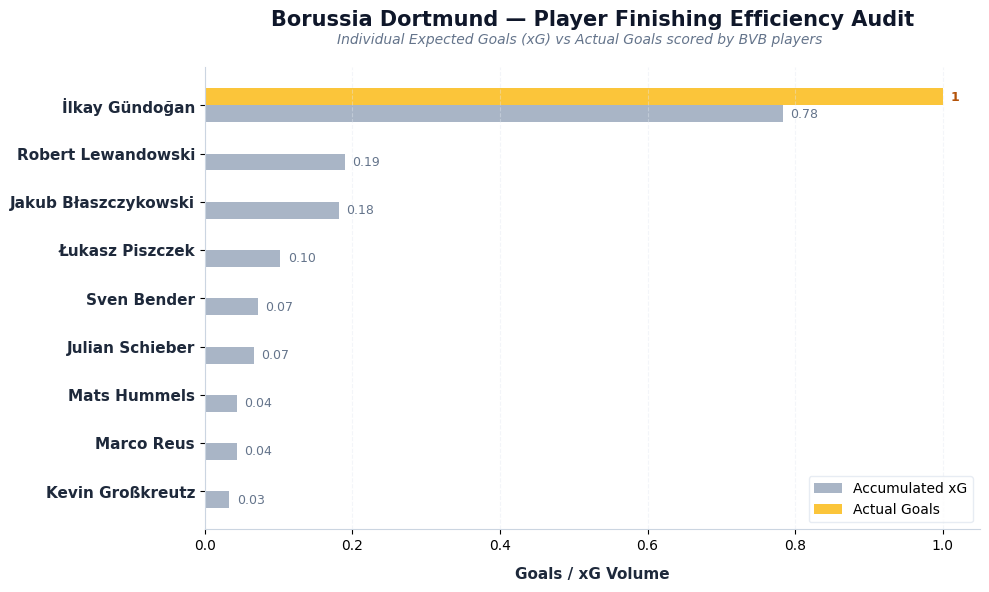

In [34]:
# =====================================================================
# STEP 10 — Dortmund Player Finishing Efficiency Audit (Goals vs. xG)
# =====================================================================

# Group shots by Dortmund players
bvb_player_audit = dortmund_shots.groupby('player').agg(
    Total_xG=('shot_statsbomb_xg', 'sum'),
    Actual_Goals=('shot_outcome', lambda x: (x == 'Goal').sum())
).reset_index()

# Sort by xG volume to see Klopp's main offensive focal points
bvb_player_audit = bvb_player_audit.sort_values(by='Total_xG', ascending=True)

# Plotting the horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#FFFFFF')
ax.set_facecolor('#FFFFFF')

y_indices = np.arange(len(bvb_player_audit))
bar_width = 0.35

# Plot dual bars (Slate Gray for xG, Dortmund Yellow for Goals)
bars_bvb_xg = ax.barh(y_indices - bar_width/2, bvb_player_audit['Total_xG'], bar_width,
                      label='Accumulated xG', color='#94A3B8', alpha=0.8)
bars_bvb_goals = ax.barh(y_indices + bar_width/2, bvb_player_audit['Actual_Goals'], bar_width,
                        label='Actual Goals', color='#FBBF24', alpha=0.9)

# Polish axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')

ax.set_yticks(y_indices)
ax.set_yticklabels(bvb_player_audit['player'], fontsize=11, fontweight='semibold', color='#1E293B')
ax.set_xlabel("Goals / xG Volume", fontsize=11, fontweight='bold', color='#1E293B', labelpad=10)

# Add text labels on bars
for bar in bars_bvb_xg:
    width = bar.get_width()
    if width > 0:
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.2f}", va='center', ha='left', fontsize=9, color='#64748B')

for bar in bars_bvb_goals:
    width = bar.get_width()
    if width > 0:
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{int(width)}", va='center', ha='left', fontsize=9, color='#B45309', fontweight='bold')

plt.title("Borussia Dortmund — Player Finishing Efficiency Audit", fontsize=15, fontweight='bold', color='#0F172A', pad=30)
fig.text(0.5, 0.92, "Individual Expected Goals (xG) vs Actual Goals scored by BVB players", color='#64748B', style='italic', ha='center', fontsize=10)

ax.legend(loc='lower right', frameon=True, facecolor='#FFFFFF', edgecolor='#E2E8F0', fontsize=10)
ax.grid(True, axis='x', linestyle='--', alpha=0.4, color='#E2E8F0')

# Save and present
plt.savefig("dortmund_player_efficiency_audit.png", dpi=300, bbox_inches='tight')
print("✅ Dortmund player audit chart successfully saved as 'dortmund_player_efficiency_audit.png'")
plt.show()

✅ Executive-ready xG flow chart successfully saved as 'ucl_final_2013_xg_timeline_flow.png'


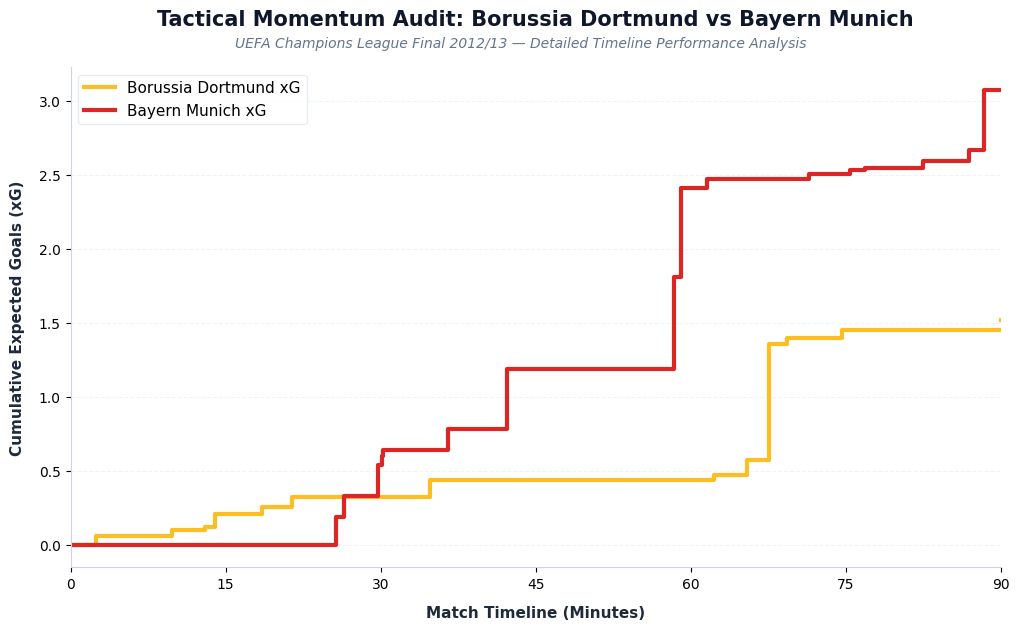

In [50]:
# =====================================================================
# STEP 11 — Compiling and Plotting Cumulative xG Timeline Flow
# =====================================================================

# 1. Isolate all shots from the match and select relevant metadata
all_shots = raw_events[raw_events['type'] == 'Shot'].copy()

# Extract minutes and add seconds normalized as a decimal for absolute chronological sorting
all_shots['total_minute'] = all_shots['minute'] + (all_shots['second'] / 60.0)

# Sort strictly by time sequence
all_shots = all_shots.sort_values(by='total_minute')

# 2. Separate shots by team
team_a = match_details['home_team'].values[0] # Borussia Dortmund
team_b = match_details['away_team'].values[0] # Bayern Munich

shots_a = all_shots[all_shots['team'] == team_a]
shots_b = all_shots[all_shots['team'] == team_b]

# 3. Build arrays starting at minute 0 with 0 xG
dict_a = {"minute": [0], "xg": [0]}
dict_b = {"minute": [0], "xg": [0]}

# Append individual shot timestamps and values
for _, shot in shots_a.iterrows():
    dict_a["minute"].append(shot['total_minute'])
    dict_a["xg"].append(shot['shot_statsbomb_xg'])

for _, shot in shots_b.iterrows():
    dict_b["minute"].append(shot['total_minute'])
    dict_b["xg"].append(shot['shot_statsbomb_xg'])

# Append full-time marker (Minute 90) to sustain the final cumulative value until the whistle
dict_a["minute"].append(90)
dict_a["xg"].append(0)
dict_b["minute"].append(90)
dict_b["xg"].append(0)

# 4. Compute Cumulative Sum (Cumulative xG)
df_flow_a = pd.DataFrame(dict_a)
df_flow_b = pd.DataFrame(dict_b)

df_flow_a['cumulative_xg'] = df_flow_a['xg'].cumsum()
df_flow_b['cumulative_xg'] = df_flow_b['xg'].cumsum()

# =====================================================================
# VISUALIZATION — Institutional Timeline Chart
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 6.5), facecolor='#FFFFFF')
ax.set_facecolor('#FFFFFF')

# Plot the step lines representing organic team momentum
ax.step(df_flow_a['minute'], df_flow_a['cumulative_xg'], where='post',
        color='#FBBF24', linewidth=3, label=f"{team_a} xG") # Dortmund Yellow
ax.step(df_flow_b['minute'], df_flow_b['cumulative_xg'], where='post',
        color='#DC2626', linewidth=3, label=f"{team_b} xG") # Bayern Munich Red

# Refine axis aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')

ax.set_xlim(0, 90)
ax.set_xticks([0, 15, 30, 45, 60, 75, 90])
ax.set_xlabel("Match Timeline (Minutes)", fontsize=11, fontweight='bold', color='#1E293B', labelpad=10)
ax.set_ylabel("Cumulative Expected Goals (xG)", fontsize=11, fontweight='bold', color='#1E293B', labelpad=10)

# Corporate headers and subtitles
plt.title(f"Tactical Momentum Audit: {team_a} vs {team_b}", fontsize=15, fontweight='bold', color='#0F172A', pad=30)
fig.text(0.5, 0.91, "UEFA Champions League Final 2012/13 — Detailed Timeline Performance Analysis",
         color='#64748B', style='italic', ha='center', fontsize=10)

# Grid styling and legend deployment
ax.grid(True, axis='y', linestyle='--', alpha=0.5, color='#E2E8F0')
ax.legend(loc='upper left', frameon=True, facecolor='#FFFFFF', edgecolor='#E2E8F0', fontsize=11)

# Export and showcase
plt.savefig("ucl_final_2013_xg_timeline_flow.png", dpi=300, bbox_inches='tight')
print("✅ Executive-ready xG flow chart successfully saved as 'ucl_final_2013_xg_timeline_flow.png'")
plt.show()